In [1]:
#import the necessary things
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

In [2]:
#sets the background grid
sns.set(style='whitegrid')

In [3]:
#load the csv files
fs = pd.read_csv('unrestricted_hcp_freesurfer.csv')
beh = pd.read_csv('HCP_YA_subjects_2026_06_11_12_41_53.csv')

print('FreeSurfer:', fs.shape)
print('Behavioral:', beh.shape)

FreeSurfer: (1113, 11)
Behavioral: (1206, 16)


In [4]:
beh_no_gender = beh.drop(columns=['Gender'])
df = pd.merge(fs, beh_no_gender, on='Subject', how='inner')
print('Merged:', df.shape)

Merged: (1113, 25)


In [5]:
#check for missing data
missing = df.isna().sum()
print(missing[missing > 0])
 
key_cols = [
    'FS_L_Amygdala_Vol', 'FS_R_Amygdala_Vol',
    'FS_L_Medialorbitofrontal_GrayVol', 'FS_R_Medialorbitofrontal_GrayVol',
    'FS_L_Rostralanteriorcingulate_GrayVol', 'FS_R_Rostralanteriorcingulate_GrayVol',
    'FS_L_Medialorbitofrontal_Thck', 'FS_R_Medialorbitofrontal_Thck',
    'FS_InterCranial_Vol',
    'PercStress_Unadj', 'SelfEff_Unadj', 'AngAffect_Unadj', 'AngHostil_Unadj', 'AngAggr_Unadj',
    'PercHostil_Unadj', 'PercReject_Unadj',
    'Flanker_Unadj', 'Flanker_AgeAdj', 'NEOFAC_A', 'NEOFAC_C',
    'Gender', 'Age'
]
key_cols = [c for c in key_cols if c in df.columns]
df = df.dropna(subset=key_cols).reset_index(drop=True)
print('After dropping missing:', df.shape)

AngAffect_Unadj     1
AngHostil_Unadj     1
PercHostil_Unadj    1
PercReject_Unadj    1
PercStress_Unadj    1
SelfEff_Unadj       1
NEOFAC_A            7
NEOFAC_C            7
AngAggr_Unadj       1
dtype: int64
After dropping missing: (1105, 25)


In [6]:
#change the categorical variables 
df['Gender_num'] = df['Gender'].map({'M': 0, 'F': 1})
 
# Age range -> numeric midpoint (e.g. '26-30' -> 28; '36+' -> 38 as an estimate)
def age_midpoint(age_str):
    if '+' in age_str:
        return float(age_str.replace('+', '')) + 2
    lo, hi = age_str.split('-')
    return (int(lo) + int(hi)) / 2
 
df['Age_mid'] = df['Age'].apply(age_midpoint)
print(df['Age_mid'].unique())
print('NaNs in Age_mid:', df['Age_mid'].isna().sum())
 

[28.  33.  23.5 38. ]
NaNs in Age_mid: 0


In [7]:
print(df['Gender_num'].unique())
print('NaNs in Gender_num:', df['Gender_num'].isna().sum())

print(df['Age_mid'].unique())
print('NaNs in Age_mid:', df['Age_mid'].isna().sum())

# spot-check the mapping looks right
print(df[['Gender', 'Gender_num', 'Age', 'Age_mid']].drop_duplicates())

[0 1]
NaNs in Gender_num: 0
[28.  33.  23.5 38. ]
NaNs in Age_mid: 0
    Gender  Gender_num    Age  Age_mid
0        M           0  26-30     28.0
1        F           1  26-30     28.0
2        M           0  31-35     33.0
4        F           1  31-35     33.0
5        M           0  22-25     23.5
19       F           1  22-25     23.5
24       F           1    36+     38.0
413      M           0    36+     38.0


In [8]:
#Combine bilateral brain measures + normalize for head size
# ---------------------------------------------------------
df['Amygdala_Vol'] = (df['FS_L_Amygdala_Vol'] + df['FS_R_Amygdala_Vol']) / 2
df['mOFC_GrayVol'] = (df['FS_L_Medialorbitofrontal_GrayVol'] + df['FS_R_Medialorbitofrontal_GrayVol']) / 2
df['rACC_GrayVol'] = (df['FS_L_Rostralanteriorcingulate_GrayVol'] + df['FS_R_Rostralanteriorcingulate_GrayVol']) / 2
df['mOFC_Thck'] = (df['FS_L_Medialorbitofrontal_Thck'] + df['FS_R_Medialorbitofrontal_Thck']) / 2
 
df['Amygdala_Vol_norm'] = df['Amygdala_Vol'] / df['FS_InterCranial_Vol']
df['mOFC_GrayVol_norm'] = df['mOFC_GrayVol'] / df['FS_InterCranial_Vol']
df['rACC_GrayVol_norm'] = df['rACC_GrayVol'] / df['FS_InterCranial_Vol']

In [9]:
# Sanity check: averaged values should fall between L and R
print(df[['FS_L_Amygdala_Vol','FS_R_Amygdala_Vol','Amygdala_Vol']].head())

# Summary stats - check for reasonable ranges, no NaNs/negatives
print(df[['Amygdala_Vol','mOFC_GrayVol','rACC_GrayVol','mOFC_Thck',
          'Amygdala_Vol_norm','mOFC_GrayVol_norm','rACC_GrayVol_norm']].describe())

# Check no NaNs were introduced
print(df[['Amygdala_Vol_norm','mOFC_GrayVol_norm','rACC_GrayVol_norm','mOFC_Thck']].isna().sum())

   FS_L_Amygdala_Vol  FS_R_Amygdala_Vol  Amygdala_Vol
0               1734               1994        1864.0
1               1536               1658        1597.0
2               1342               1856        1599.0
3               1848               2123        1985.5
4               1524               1277        1400.5
       Amygdala_Vol  mOFC_GrayVol  rACC_GrayVol    mOFC_Thck  \
count   1105.000000   1105.000000   1105.000000  1105.000000   
mean    1597.078281   5804.725792   2738.029412     2.653571   
std      201.127480    690.800644    498.137588     0.122901   
min     1077.500000   4180.500000   1374.000000     2.042500   
25%     1452.000000   5293.000000   2396.000000     2.568500   
50%     1581.500000   5769.000000   2678.500000     2.649500   
75%     1726.000000   6233.000000   3053.000000     2.731500   
max     2407.500000   8451.000000   4499.500000     3.125500   

       Amygdala_Vol_norm  mOFC_GrayVol_norm  rACC_GrayVol_norm  
count        1105.000000        11

In [10]:
# Define brain variables of interest (normalized for head size)
brain_vars = ['Amygdala_Vol_norm', 'mOFC_GrayVol_norm', 'rACC_GrayVol_norm', 'mOFC_Thck']

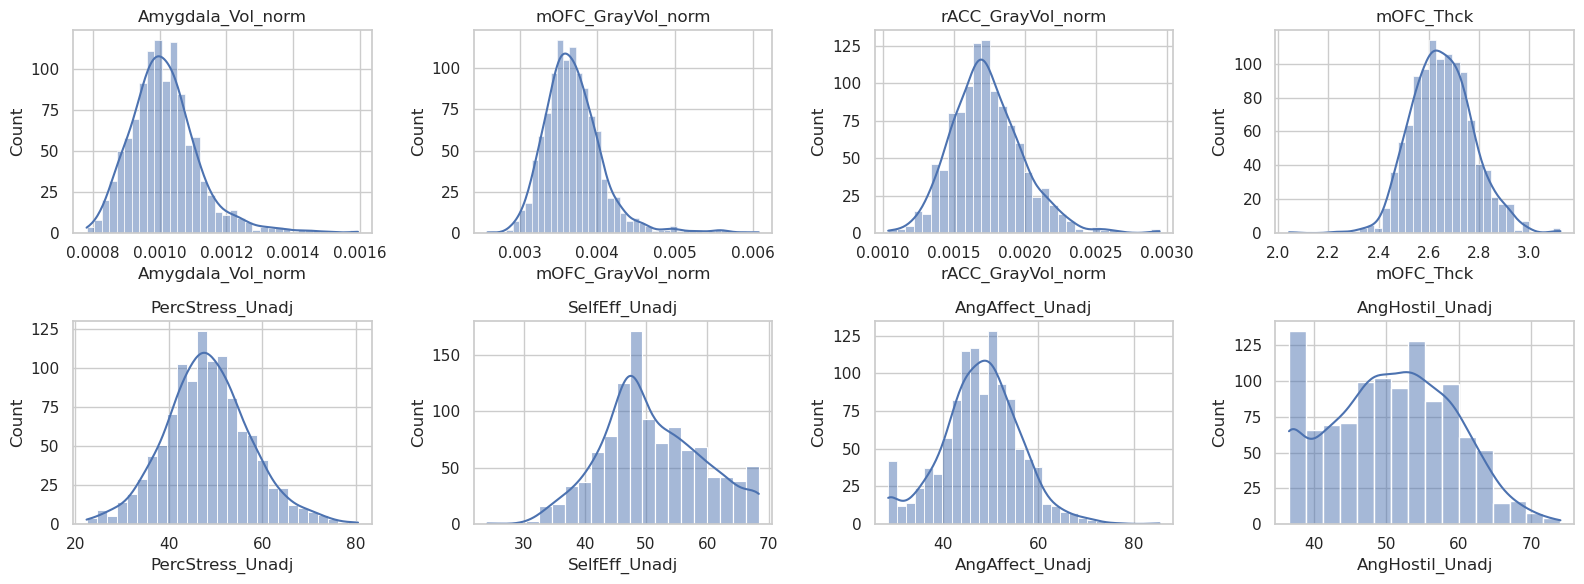

Amygdala_Vol_norm: 6 outliers (>4 SD)
mOFC_GrayVol_norm: 10 outliers (>4 SD)
rACC_GrayVol_norm: 3 outliers (>4 SD)
mOFC_Thck: 1 outliers (>4 SD)


In [11]:
# Distributions / outlier check
behav_vars = ['PercStress_Unadj', 'SelfEff_Unadj', 'AngAffect_Unadj', 'AngHostil_Unadj',
              'AngAggr_Unadj', 'PercHostil_Unadj', 'PercReject_Unadj',
              'Flanker_Unadj', 'Flanker_AgeAdj', 'NEOFAC_A', 'NEOFAC_C']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, brain_vars + behav_vars[:4]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
 
for col in brain_vars:
    z = np.abs(stats.zscore(df[col]))
    n_out = (z > 4).sum()
    print(f'{col}: {n_out} outliers (>4 SD)')
 
#drop extreme outliers:
df = df[(np.abs(stats.zscore(df[brain_vars])) < 4).all(axis=1)]
 

In [12]:
#standardise Z scores
z_cols = brain_vars + behav_vars + ['Age_mid']
for col in z_cols:
    df[col + '_z'] = stats.zscore(df[col])
 

In [13]:
#check that Zscores were calculated properly
# Check that all _z columns exist
z_cols_check = [c + '_z' for c in (brain_vars + behav_vars + ['Age_mid'])]
print(z_cols_check)
print([c in df.columns for c in z_cols_check])

# z-scored columns should have mean ~0 and std ~1
print(df[z_cols_check].describe().loc[['mean', 'std']])

# No NaNs introduced
print(df[z_cols_check].isna().sum())

# Spot-check: original vs z-scored for one variable
print(df[['PercStress_Unadj', 'PercStress_Unadj_z']].head())

['Amygdala_Vol_norm_z', 'mOFC_GrayVol_norm_z', 'rACC_GrayVol_norm_z', 'mOFC_Thck_z', 'PercStress_Unadj_z', 'SelfEff_Unadj_z', 'AngAffect_Unadj_z', 'AngHostil_Unadj_z', 'AngAggr_Unadj_z', 'PercHostil_Unadj_z', 'PercReject_Unadj_z', 'Flanker_Unadj_z', 'Flanker_AgeAdj_z', 'NEOFAC_A_z', 'NEOFAC_C_z', 'Age_mid_z']
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
      Amygdala_Vol_norm_z  mOFC_GrayVol_norm_z  rACC_GrayVol_norm_z  \
mean        -2.187792e-16        -4.285787e-16        -9.796086e-18   
std          1.000460e+00         1.000460e+00         1.000460e+00   

       mOFC_Thck_z  PercStress_Unadj_z  SelfEff_Unadj_z  AngAffect_Unadj_z  \
mean  1.387779e-15        6.669502e-16     9.347098e-16      -9.224647e-17   
std   1.000460e+00        1.000460e+00     1.000460e+00       1.000460e+00   

      AngHostil_Unadj_z  AngAggr_Unadj_z  PercHostil_Unadj_z  \
mean       1.632681e-18     1.551047e-16       -6.987874e-16   
std        1.00

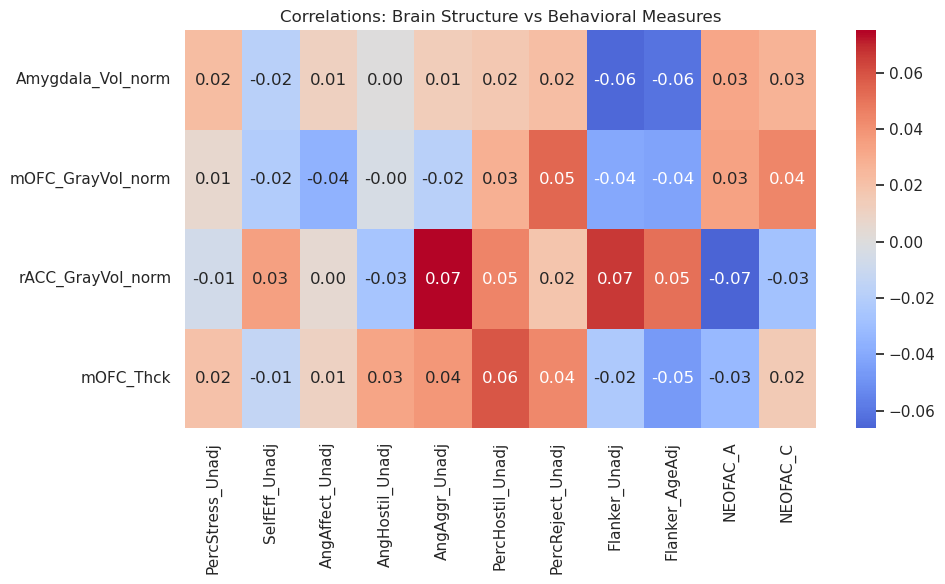

In [14]:
#correlation matrix
corr_df = df[brain_vars + behav_vars]
corr_matrix = corr_df.corr()
 
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix.loc[brain_vars, behav_vars], annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlations: Brain Structure vs Behavioral Measures')
plt.tight_layout()
plt.show()

Based on the correlation heatmap, all correlations between brain structure and behavioral measures is very weak (|r| ≤ 0.08). 

The largest are: rACC_GrayVol_norm vs AngAggr_Unadj (r ≈ 0.08), Amygdala_Vol_norm vs Flanker_Unadj/Flanker_AgeAdj (r ≈ -0.08), and rACC_GrayVol_norm vs NEOFAC_A (r ≈ -0.07).

However, with around 1100 subjects, r ≈ 0.06–0.08 — while potentially statistically significant — would explain less than 1% of variance, and likely represents a weak/null pattern that does not meaningfully explain brain-behaviour links.

In [15]:
#since there are 44 pairs we would use benjamini hochberg fdr correction
from itertools import product
from statsmodels.stats.multitest import multipletests
 
results = []
for b_var, beh_var in product(brain_vars, behav_vars):
    r, p = stats.pearsonr(df[b_var], df[beh_var])
    results.append({'brain_var': b_var, 'behav_var': beh_var, 'r': r, 'r_squared': r**2, 'p': p})
 
corr_results = pd.DataFrame(results)
 
reject, p_fdr, _, _ = multipletests(corr_results['p'], alpha=0.05, method='fdr_bh')
corr_results['p_fdr'] = p_fdr
corr_results['significant_fdr'] = reject
 
print(corr_results.sort_values('p').head(10))
print('\nNumber of pairs surviving FDR correction (q < 0.05):', corr_results['significant_fdr'].sum())

            brain_var         behav_var         r  r_squared         p  \
26  rACC_GrayVol_norm     AngAggr_Unadj  0.074976   0.005621  0.013371   
29  rACC_GrayVol_norm     Flanker_Unadj  0.066517   0.004425  0.028238   
31  rACC_GrayVol_norm          NEOFAC_A -0.066271   0.004392  0.028829   
7   Amygdala_Vol_norm     Flanker_Unadj -0.064793   0.004198  0.032600   
8   Amygdala_Vol_norm    Flanker_AgeAdj -0.061180   0.003743  0.043634   
38          mOFC_Thck  PercHostil_Unadj  0.058492   0.003421  0.053756   
17  mOFC_GrayVol_norm  PercReject_Unadj  0.053976   0.002913  0.075135   
30  rACC_GrayVol_norm    Flanker_AgeAdj  0.050734   0.002574  0.094402   
41          mOFC_Thck    Flanker_AgeAdj -0.046368   0.002150  0.126385   
27  rACC_GrayVol_norm  PercHostil_Unadj  0.045038   0.002028  0.137645   

       p_fdr  significant_fdr  
26  0.358603            False  
29  0.358603            False  
31  0.358603            False  
7   0.358603            False  
8   0.383978            F

To address the multiple comparisons problem, we created composite variables: an aggression/hostility score (averaging related anger/hostility items) and an amygdala-PFC balance score (reflecting the regulatory circuit hypothesis)

In [16]:
#Composite 1: Aggression/Hostility composite
# Average of z-scored anger/hostility/rejection-perception subscales
aggression_items = ['AngAffect_Unadj_z', 'AngHostil_Unadj_z', 'AngAggr_Unadj_z',
                     'PercHostil_Unadj_z', 'PercReject_Unadj_z']
df['Aggression_composite'] = df[aggression_items].mean(axis=1)

In [17]:
#Composite 2: Amygdala-PFC regulation balance
# Higher = relatively larger amygdala vs. regulatory regions (mOFC + rACC)
df['Amyg_PFC_balance'] = df['Amygdala_Vol_norm_z'] - df[['mOFC_GrayVol_norm_z', 'rACC_GrayVol_norm_z']].mean(axis=1)


In [18]:
#checks ---
print(df[aggression_items + ['Aggression_composite']].describe())
print(df[['Amygdala_Vol_norm_z','mOFC_GrayVol_norm_z','rACC_GrayVol_norm_z','Amyg_PFC_balance']].describe())


       AngAffect_Unadj_z  AngHostil_Unadj_z  AngAggr_Unadj_z  \
count       1.088000e+03       1.088000e+03     1.088000e+03   
mean       -9.224647e-17       1.632681e-18     1.551047e-16   
std         1.000460e+00       1.000460e+00     1.000460e+00   
min        -2.335966e+00      -1.625611e+00    -9.727021e-01   
25%        -5.893260e-01      -7.528781e-01    -9.727021e-01   
50%         2.927566e-02       4.396502e-02    -4.291670e-02   
75%         5.993595e-01       7.444865e-01     7.281248e-01   
max         4.553558e+00       2.740973e+00     3.528820e+00   

       PercHostil_Unadj_z  PercReject_Unadj_z  Aggression_composite  
count        1.088000e+03        1.088000e+03          1.088000e+03  
mean        -6.987874e-16        3.885781e-16         -5.796017e-17  
std          1.000460e+00        1.000460e+00          7.171846e-01  
min         -1.762087e+00       -1.428289e+00         -1.624931e+00  
25%         -5.756954e-01       -8.802694e-01         -4.804870e-01  
50%

In [19]:
# Internal consistency of the aggression composite (Cronbach's alpha)
import numpy as np
def cronbach_alpha(items_df):
    item_vars = items_df.var(axis=0, ddof=1)
    total_var = items_df.sum(axis=1).var(ddof=1)
    n_items = items_df.shape[1]
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)

print('Cronbach alpha (aggression composite):', cronbach_alpha(df[aggression_items]))

Cronbach alpha (aggression composite): 0.7635060055908074


Since cronbach alpha is above 0.7, this means the 5 items are reasonably internally consistent and it's defensible to treat them as one underlying "aggression/hostility" construct rather than 5 separate variables.

In [20]:
model_interact = smf.ols(
    'Aggression_composite ~ Amyg_PFC_balance * Gender_num + Amyg_PFC_balance * Age_mid_z + Age_mid_z + Gender_num',
    data=df).fit()
print(model_interact.summary())

                             OLS Regression Results                             
Dep. Variable:     Aggression_composite   R-squared:                       0.033
Model:                              OLS   Adj. R-squared:                  0.028
Method:                   Least Squares   F-statistic:                     7.293
Date:                  Thu, 11 Jun 2026   Prob (F-statistic):           9.87e-07
Time:                          17:26:58   Log-Likelihood:                -1163.6
No. Observations:                  1088   AIC:                             2339.
Df Residuals:                      1082   BIC:                             2369.
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

the main effect of brain structure on aggression is null, but exploratory interaction analyses suggest this relationship may be moderated by age (p=0.034) and possibly sex (p=0.054); given the small effect sizes and lack of correction for these additional tests, these findings should be considered preliminary and would need replication in an independent sample.

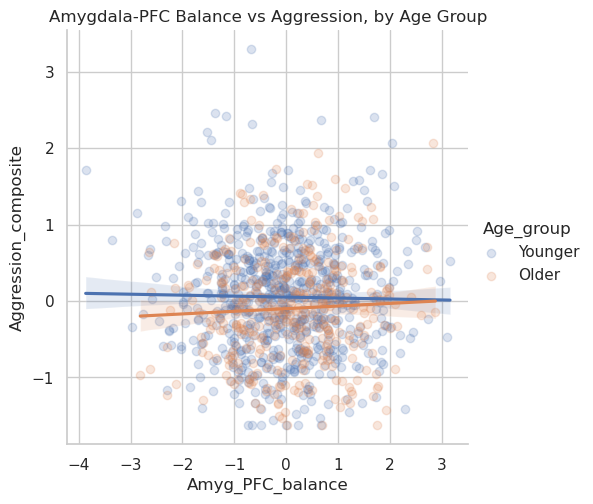

In [21]:
import seaborn as sns

# Median split just for visualization (not for the actual stats)
df['Age_group'] = np.where(df['Age_mid_z'] > df['Age_mid_z'].median(), 'Older', 'Younger')

sns.lmplot(data=df, x='Amyg_PFC_balance', y='Aggression_composite',
           hue='Age_group', scatter_kws={'alpha':0.2})
plt.title('Amygdala-PFC Balance vs Aggression, by Age Group')
plt.show()